In [2]:
from sklearn.datasets import load_iris 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 

iris = load_iris()
X , y = iris.data , iris.target 

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

print(f"PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

PC1: 72.96%
PC2: 22.85%
Total Variance Explained: 95.81%


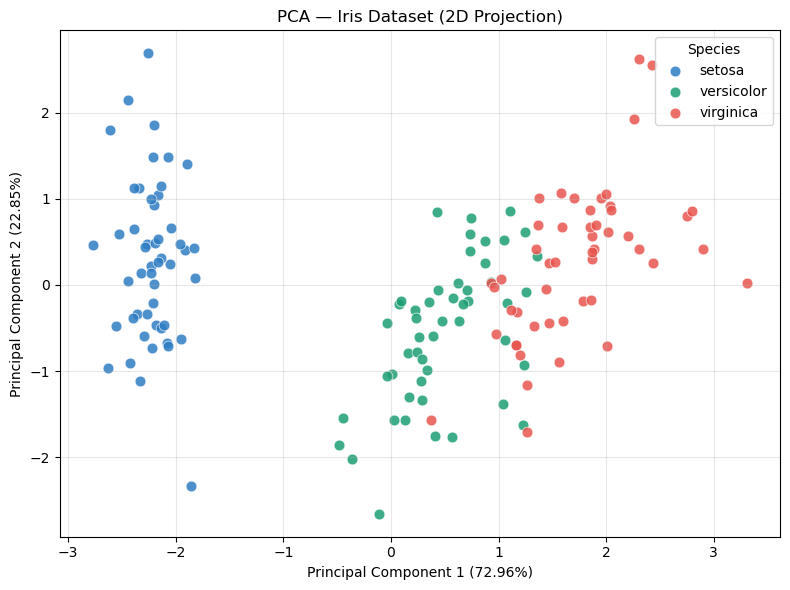

In [4]:
import matplotlib.pyplot as plt
colors = ['#2E7DC4', '#1D9E75', '#E8554E']
labels = iris.target_names   # ['setosa', 'versicolor', 'virginica']

plt.figure(figsize=(8, 6))
for i, (label, color) in enumerate(zip(labels, colors)):
    mask = y == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=label, s=60,
                edgecolors='white', linewidths=0.5, alpha=0.85)

plt.xlabel('Principal Component 1 (72.96%)')
plt.ylabel('Principal Component 2 (22.85%)')
plt.title('PCA — Iris Dataset (2D Projection)')
plt.legend(title='Species')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

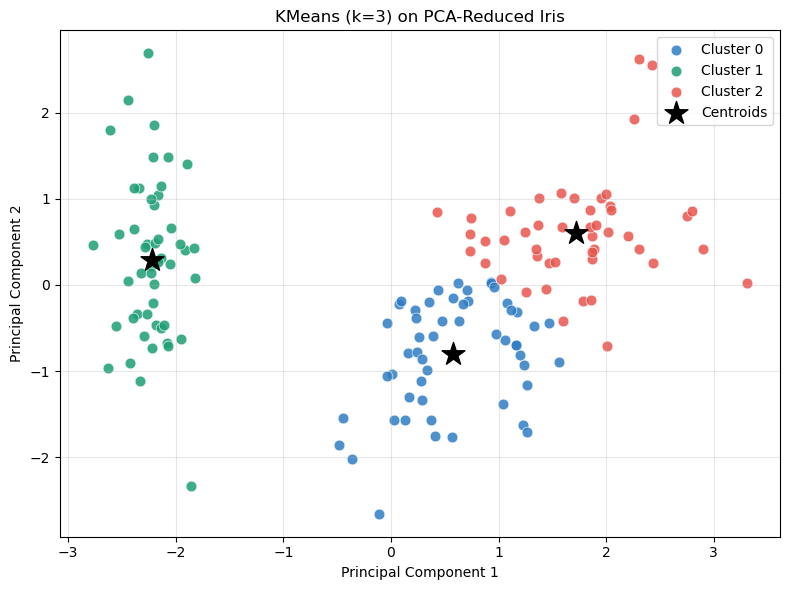

Cluster sizes: {0: np.int64(53), 1: np.int64(50), 2: np.int64(47)}


In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

iris = load_iris()
X , y = iris.data , iris.target 

X_scaled = StandardScaler().fit_transform(X)
X_pca    = PCA(n_components=2).fit_transform(X_scaled)


km = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_pca)
centroids = km.cluster_centers_

colors = ['#2E7DC4', '#1D9E75', '#E8554E']

plt.figure(figsize=(8, 6))
for i in range(3):
    mask = cluster_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                s=60, edgecolors='white', linewidths=0.5, alpha=0.85)

plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', marker='*', s=300,
            zorder=6, label='Centroids')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('KMeans (k=3) on PCA-Reduced Iris')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Cluster sizes:", {i: (cluster_labels==i).sum() for i in range(3)})

